# **A** **Machine Learning Pipeline for Diabetes Diagnosis Prediction**

**1.Python libraries and some settings for the set plot for the better visualisation**

In [ ]:
import warnings
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from google.colab import files
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


sns.set(style="whitegrid")
plt.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore')

I imported all the Python libraries here that are needed for data handling, plots and machine‑learning models, then I set a clean white‑grid style for plots, use higher‑resolution figures, and switch off minor warning messages so the notebook output is easier to read.​

**2. Load Dataset file into the model**

In [ ]:
print("Please upload 'diabetes.csv' file:")
uploaded = files.upload()

if uploaded:
    file_name = list(uploaded.keys())[0]
    print(f"\nfile have been successfully uploaded")

    try:
        df = pd.read_csv(io.BytesIO(uploaded[file_name]))

        print("First 5 Rows of the dataset")
        display(df.head())
    except Exception as e:
        print(f" Error in loading CSV file: {e}")
        raise
else:
    print(" Error: No file uploaded please try again.")

Please upload 'diabetes.csv' file:


Saving diabetes_extended_noisy (3).csv to diabetes_extended_noisy (3) (6).csv

file have been successfully uploaded
First 5 Rows of the dataset


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,PhysicalActivityLevel,FamilyHistory
0,2,90.0,60,0.0,0.0,23.5,0.191,25,0,2,NaN
1,1,112.0,80,45.0,132.0,34.8,0.217,24,0,2,NaN
2,2,141.0,58,34.0,128.0,25.4,0.699,24,0,2,Moderate
3,6,91.0,0,0.0,0.0,29.8,0.501,31,0,1,Moderate
4,0,109.0,88,30.0,0.0,32.5,0.855,38,1,2,Strong


# EDA (Exploratory Data Analysis)

**3. Dataset structure (shape, column types, and missing values)**

In [ ]:
if 'df' in locals():
    print(f"Total Rows={df.shape[0]} Columns= {df.shape[1]}")
    print('\nData type of each columns\n')
    print(df.dtypes)

    print('\nMissing values in the dataset\n')
    print(df.isnull().sum())
else:
    print(" 'df' is not loaded ")

Total Rows=798 Columns= 11

Data type of each columns

Pregnancies                   int64
Glucose                     float64
BloodPressure                 int64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
PhysicalActivityLevel         int64
FamilyHistory                object
dtype: object

Missing values in the dataset

Pregnancies                   0
Glucose                       0
BloodPressure                 0
SkinThickness                16
Insulin                      16
BMI                          16
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
PhysicalActivityLevel         0
FamilyHistory               432
dtype: int64


## **Observations:**
From the above analysis it is clear that the database contains 798 rows and 11 columns.

 The 11 features are:
 - 8 numerical predictors: `Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, `Age`
- 2 categorical predictors: `PhysicalActivityLevel` (int), `FamilyHistory` (object)
 - 1 target variable: `Outcome` (int)

**4. Duplicate Records in the dataset**

In [ ]:
if 'df' in locals():
    print('Duplicate Records in the dataset')
    dup_count = df.duplicated().sum()
    print(f'Number of duplicate rows: {dup_count}')
    if dup_count > 0:
        print("Showing duplicate rows    ")
        display(df[df.duplicated()])

else:
    print(" Error: 'df' not loaded ")

Duplicate Records in the dataset
Number of duplicate rows: 28
Showing duplicate rows    


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,PhysicalActivityLevel,FamilyHistory
117,0,117.0,0,0.0,0.0,33.8,0.932,44,0,1,Strong
118,7,184.0,84,33.0,0.0,35.5,0.355,41,1,3,NaN
153,1,71.0,48,18.0,76.0,20.4,0.323,22,0,2,NaN
219,10,129.0,76,28.0,122.0,35.9,0.280,39,0,2,NaN
253,7,179.0,95,31.0,0.0,34.2,0.164,60,0,1,NaN
264,3,84.0,72,32.0,0.0,37.2,0.267,28,0,2,NaN
282,2,102.0,86,36.0,120.0,45.5,0.127,23,1,2,NaN
319,5,96.0,74,18.0,67.0,33.6,0.997,43,0,1,Strong
375,1,88.0,78,29.0,76.0,32.0,0.365,29,0,1,NaN
406,3,89.0,74,16.0,85.0,30.4,0.551,38,0,1,Moderate


There were 28 duplicate rows are present in the dataset.

**5. Invalid zero values are replaced  with NaN because medically zero is considered as invalid data.**

In [ ]:
if 'df' in locals():

    cols_with_zeros = ['Glucose', 'BloodPressure', 'BMI', 'SkinThickness', 'Insulin']
    zero_counts_before = (df[cols_with_zeros] == 0).sum()
    print("Total Zero's values before replacement")
    print(zero_counts_before)
    df_cleaned = df.copy()
    df_cleaned[cols_with_zeros] = df_cleaned[cols_with_zeros].replace(0, np.nan)
    print('\nMissing values after zero to  NaN replacement\n')
    print(df_cleaned.isnull().sum())
    converted = df_cleaned.isnull().sum()[cols_with_zeros] - df.isnull().sum()[cols_with_zeros]
    print('\nNumber of zeros converted to NaN\n')
    print(converted)
else:
    print(" Error: 'df' not loaded.")


Total Zero's values before replacement
Glucose            5
BloodPressure     37
BMI               10
SkinThickness    229
Insulin          381
dtype: int64

Missing values after zero to  NaN replacement

Pregnancies                   0
Glucose                       5
BloodPressure                37
SkinThickness               245
Insulin                     397
BMI                          26
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
PhysicalActivityLevel         0
FamilyHistory               432
dtype: int64

Number of zeros converted to NaN

Glucose            5
BloodPressure     37
BMI               10
SkinThickness    229
Insulin          381
dtype: int64


So there were many zero values present in the dataset such as: Glucose, BloodPressure, BMI, SkinThickness, Insulin have ( 5,37,10,229,381) zero values respectively

**6. Percentage of missing data
(measuring how much information is missing per column)**

In [ ]:
if 'df_cleaned' in locals():
    missing_prop = (df_cleaned.isnull().sum() / len(df_cleaned) * 100).round(2)
    print('Missing value proportions (%)    ')
    print(missing_prop.sort_values(ascending=False))
else:
    print(" Error: 'df_cleaned' not created.")

Missing value proportions (%)    
FamilyHistory               54.14
Insulin                     49.75
SkinThickness               30.70
BloodPressure                4.64
BMI                          3.26
Glucose                      0.63
Pregnancies                  0.00
DiabetesPedigreeFunction     0.00
Age                          0.00
Outcome                      0.00
PhysicalActivityLevel        0.00
dtype: float64


 After converting these invalid zeros value to NaN, I calculated the exact proprortion missing data picture:
- FamilyHistory: 432 missing (54.14%)
- Insulin: 397 missing (49.75%)
- SkinThickness: 245 missing (30.70%)
- BloodPressure: 37 missing (4.64%)
- BMI: 26 missing (3.26%)
- Glucose: 5 missing (0.63%)

**7. Visual heatmap of missing data
(:where NaN values appear in the dataset)**

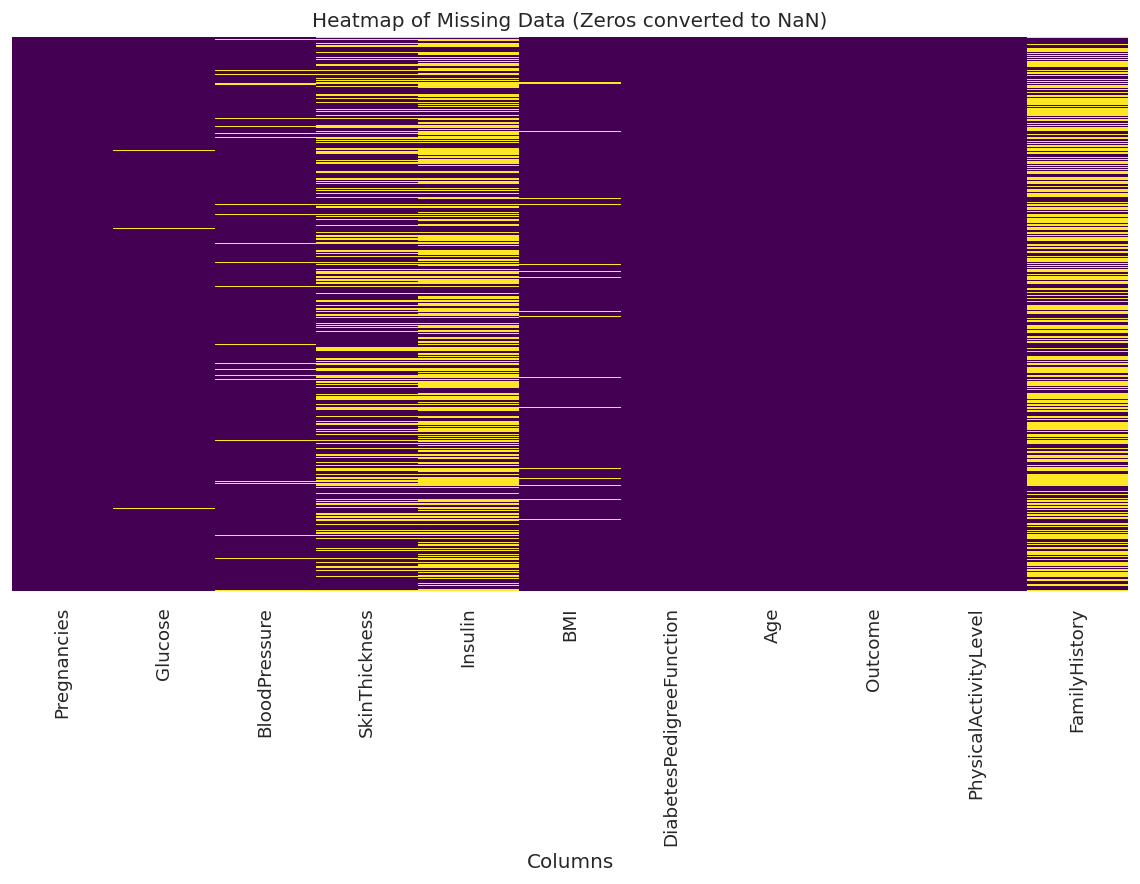

In [ ]:
if 'df_cleaned' in locals():
    plt.figure(figsize=(12, 6))
    sns.heatmap(df_cleaned.isnull(), cbar=False, cmap='viridis', yticklabels=False)
    plt.title('Heatmap of Missing Data (Zeros converted to NaN)')
    plt.xlabel('Columns')
    plt.show()
else:
    print(" Error: 'df_cleaned' not created.")

 The missing data heatmap visually confirms is huge gaps between the columns `FamilyHistory`, `Insulin`, and `SkinThickness`.


**8. Histograms of numeric features
(check how each numerical variable is distributed)**

Plotting histograms for: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


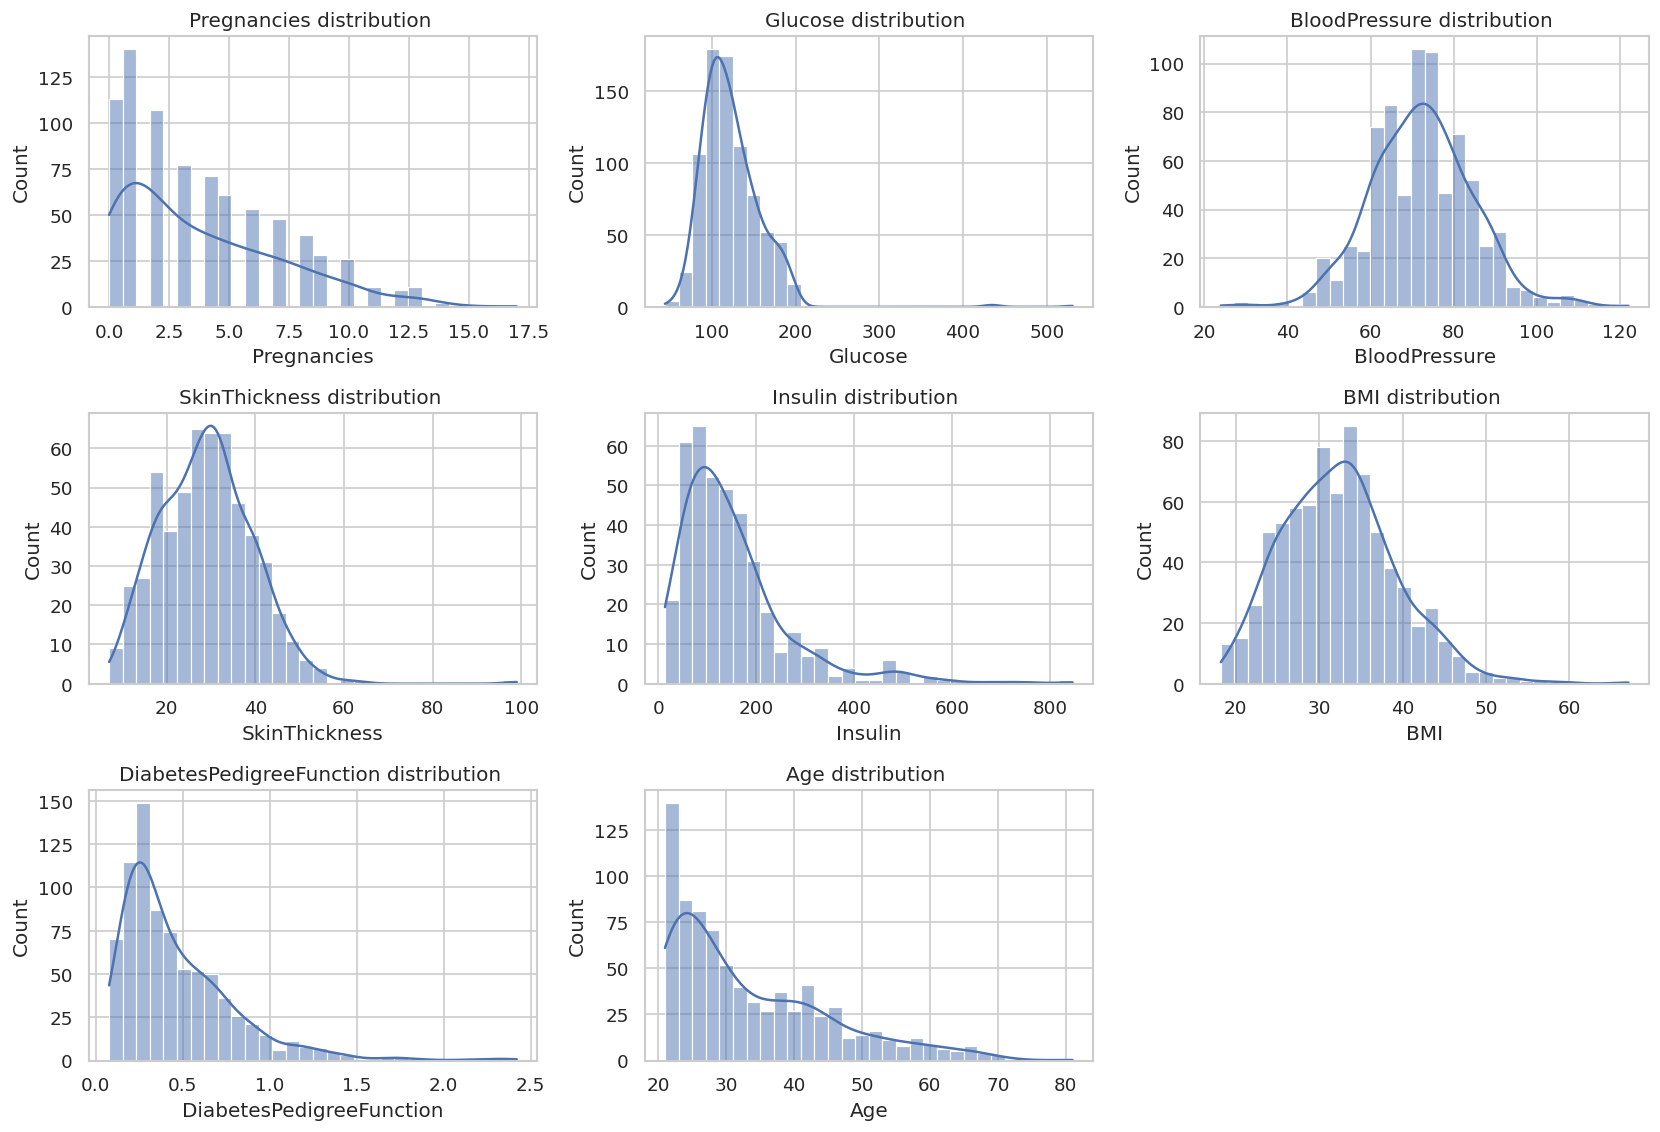

In [ ]:

if 'df_cleaned' in locals():
    numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()
    if 'Outcome' in numeric_cols:
        numeric_cols.remove('Outcome')
    if 'PhysicalActivityLevel' in numeric_cols:
        numeric_cols.remove('PhysicalActivityLevel')

    print('Plotting histograms for:', numeric_cols)

    cols = 3
    rows = int(np.ceil(len(numeric_cols) / cols))
    plt.figure(figsize=(14, rows * 3.2))
    for i, col in enumerate(numeric_cols):
        plt.subplot(rows, cols, i + 1)
        sns.histplot(df_cleaned[col].dropna(), bins=30, kde=True)
        plt.title(f'{col} distribution ')
        plt.xlabel(col)
    plt.tight_layout()
    plt.show()
else:
    print(" Error: 'df_cleaned' not created.")

 Going through histograms where
 - `BloodPressure` and `BMI` show a nice, normal distribution.
 - `Age`, `Pregnancies`, `DiabetesPedigreeFunction`, `Insulin`, and `SkinThickness` are all right-skewed, meaning most patients have values on the lower end of these scales.

**9. Bar plots for FamilyHistory and PhysicalActivityLevel
(let's see how many patients fall into each category)**

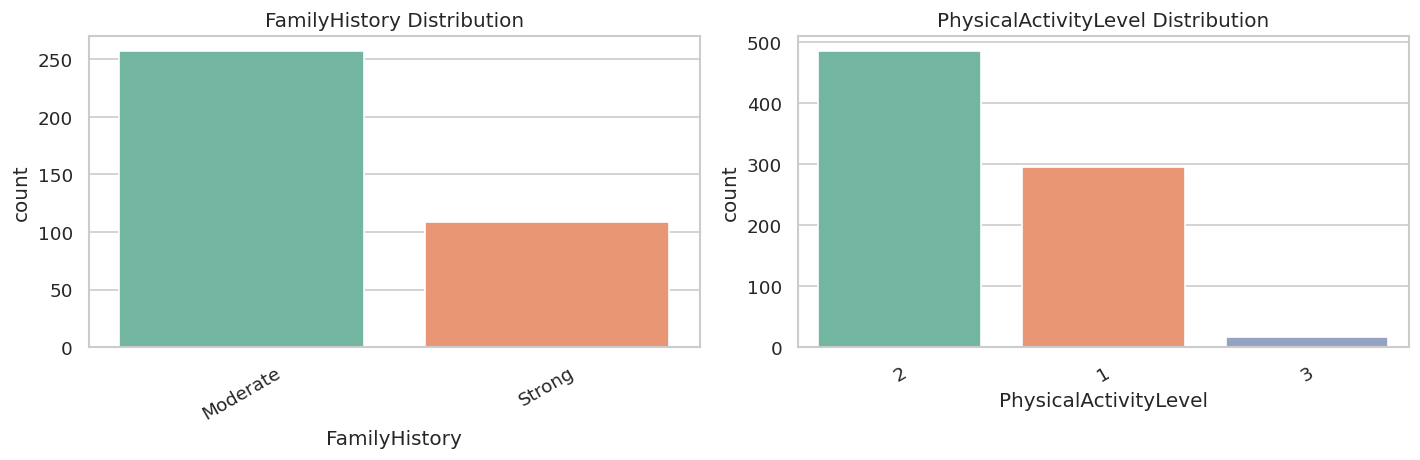

In [ ]:

if 'df' in locals():
    categorical_cols = ['FamilyHistory', 'PhysicalActivityLevel']

    plt.figure(figsize=(12, 4))
    for i, col in enumerate(categorical_cols):
        if col in df.columns:
            plt.subplot(1, 2, i + 1)
            ax = sns.countplot(x=col, data=df, palette='Set2', order=df[col].value_counts().index)
            plt.title(f'{col} Distribution')
            plt.xlabel(col)
            plt.xticks(rotation=30)
        else:
            print(f"Warning: Column '{col}' not found for countplot.")
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'df' not loaded.")

 Categorical columns Distributions shows
 - `FamilyHistory` of the non-missing data, Moderate (around 260) is more common than Strong ( around 110).
 - `PhysicalActivityLevel` is clearly categorical. Level 2 is the most common, followed by 1, and 3 is rare.

**10. Boxplots of key features against Outcome
(compare values for people with and without diabetes)**

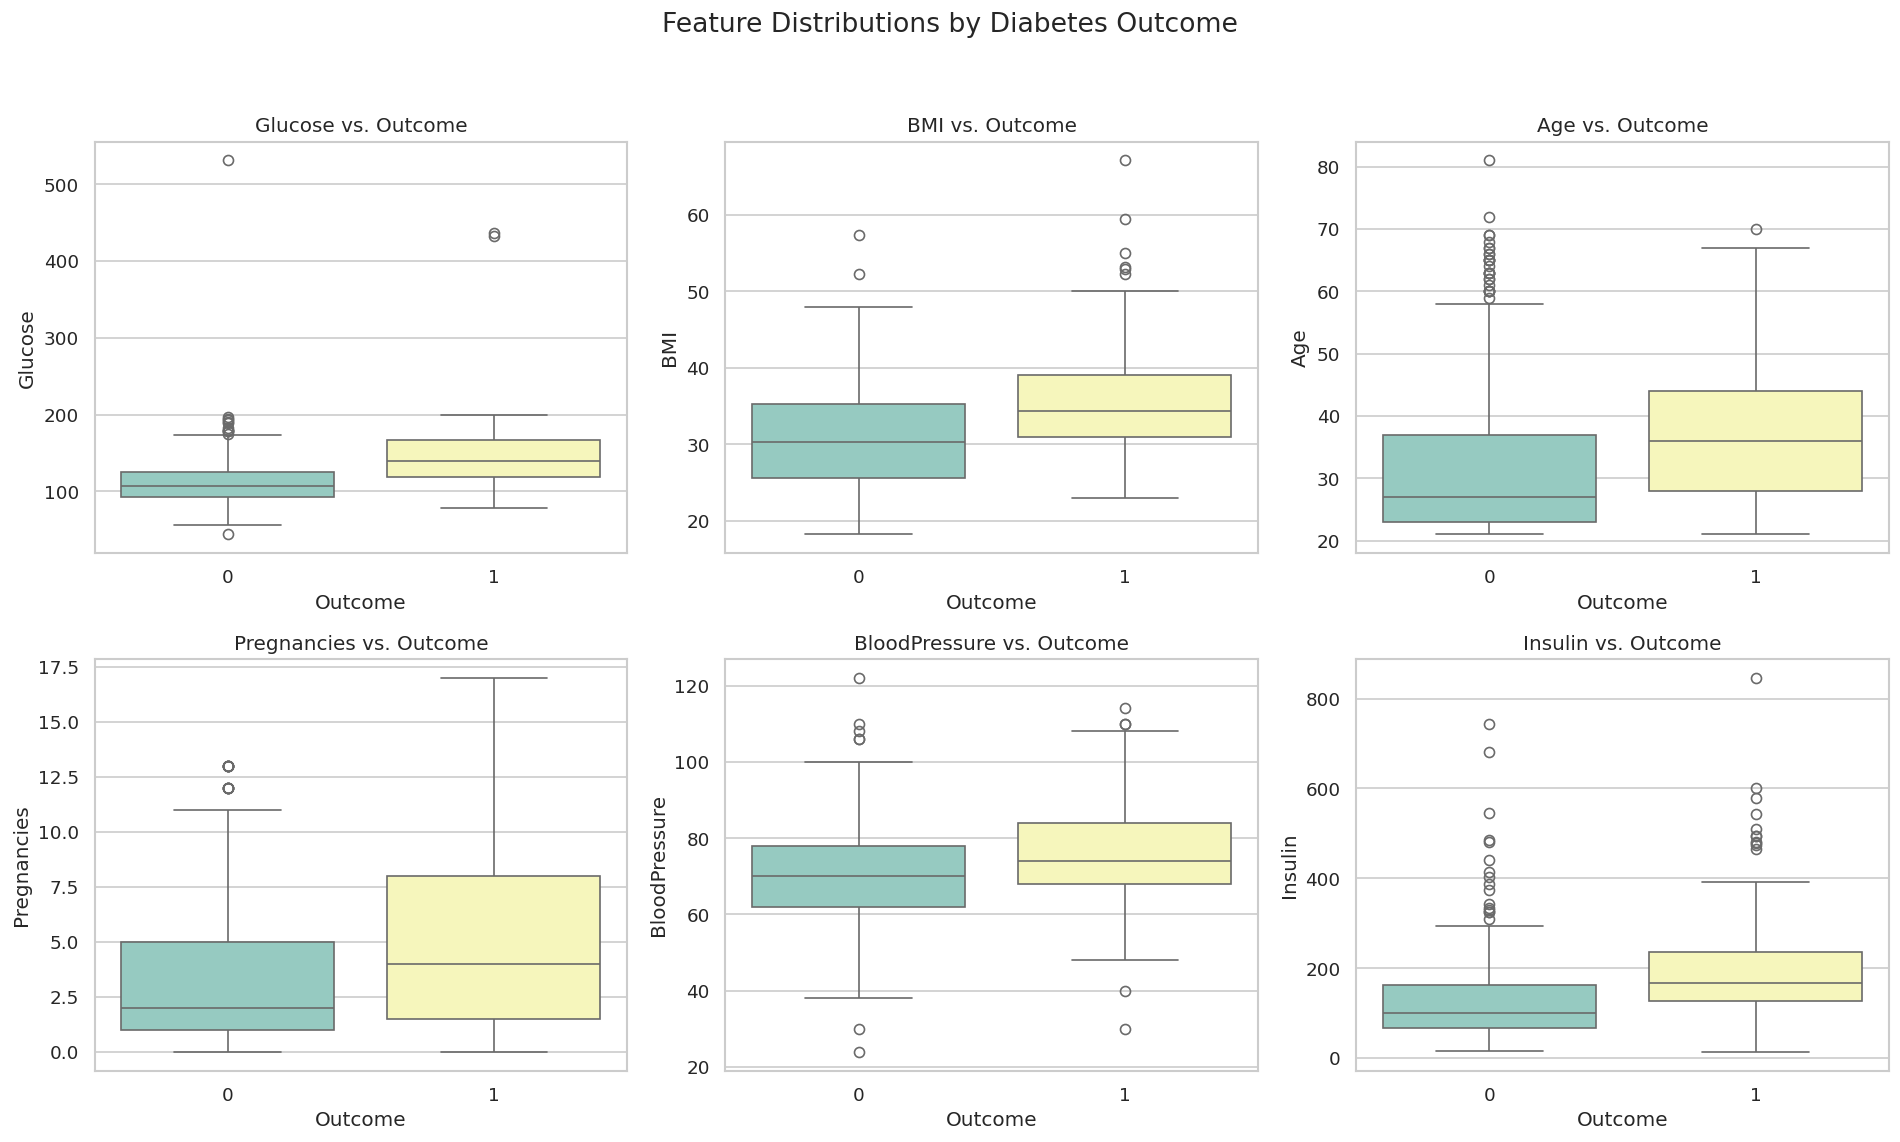

In [ ]:
if 'df_cleaned' in locals():

    features_to_plot = ['Glucose', 'BMI', 'Age', 'Pregnancies', 'BloodPressure', 'Insulin']
    plt.figure(figsize=(16, 10))
    for i, feature in enumerate(features_to_plot):
        if feature in df_cleaned.columns:
            plt.subplot(2, 3, i + 1)
            sns.boxplot(x='Outcome', y=feature, data=df_cleaned, palette='Set3')
            plt.title(f'{feature} vs. Outcome')
        else:
            print(f"Warning: Column '{feature}' not found for boxplot.")
    plt.suptitle('Feature Distributions by Diabetes Outcome', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("Error: 'df_cleaned' not created.")

 The boxplots confirm these findings perfectly. For `Glucose`, `BMI`, `Age`, and `Pregnancies`, the median value for the 'Positive' (1) group is clearly higher than for the 'Negative' (0) group.


**11.Correlation heatmap for numeric features to see how strongly each numeric column is related to Outcome and to each other**

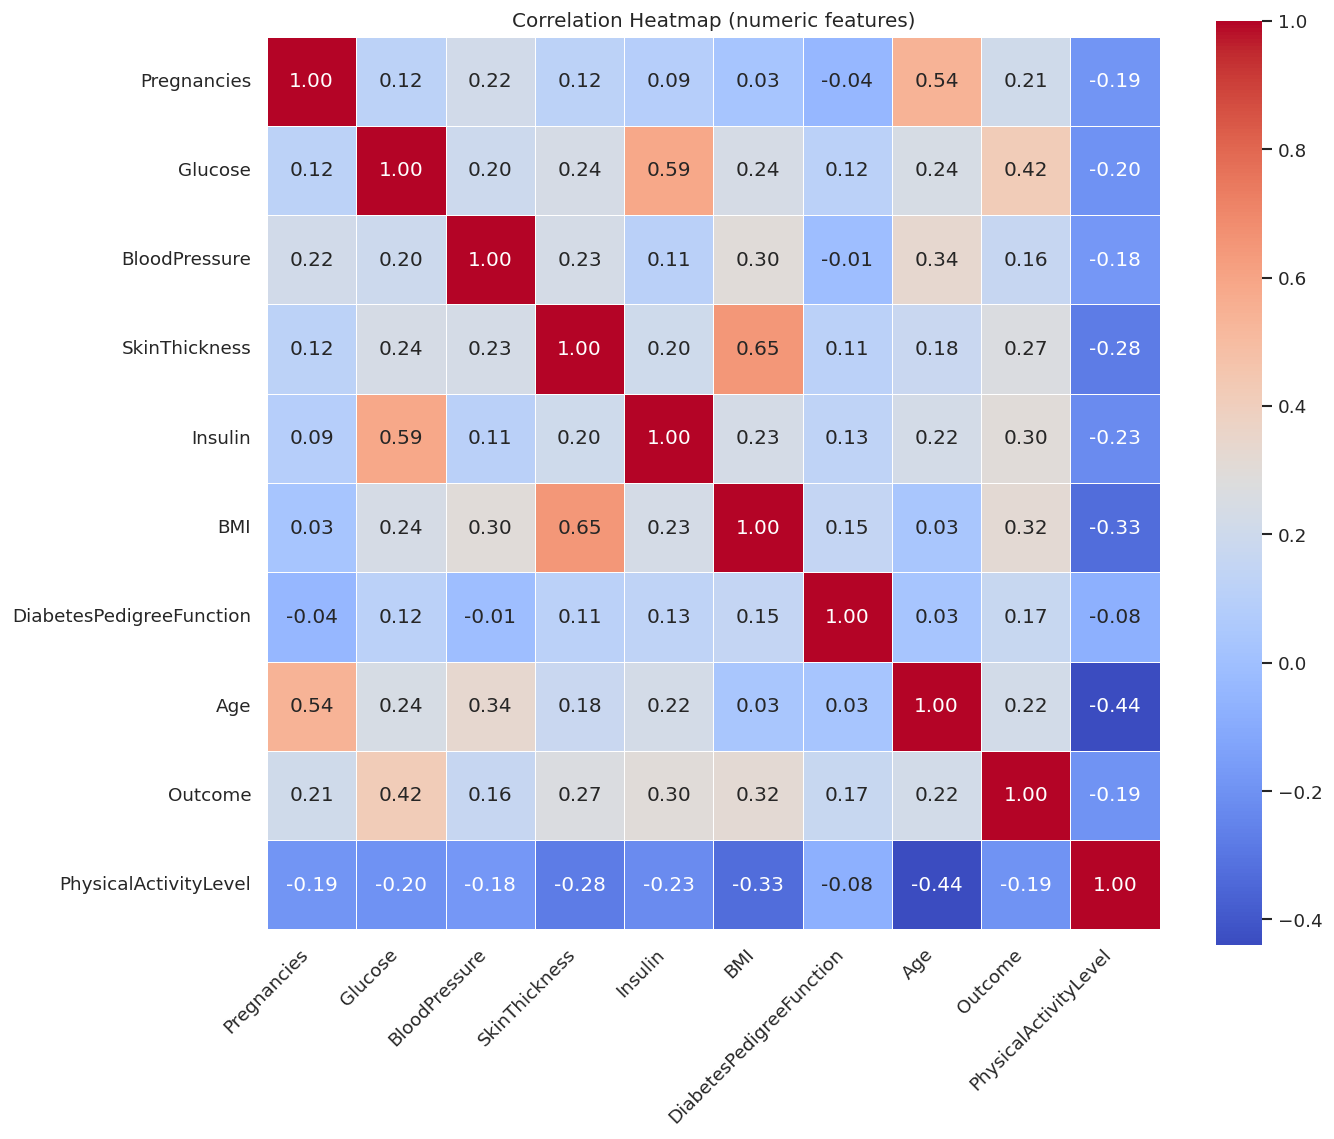


Top correlations with Outcome    
Glucose                     0.420356
BMI                         0.317989
Insulin                     0.299540
SkinThickness               0.268260
Age                         0.221896
Pregnancies                 0.211154
PhysicalActivityLevel      -0.193977
DiabetesPedigreeFunction    0.169876
BloodPressure               0.163946
Name: Outcome, dtype: float64


In [ ]:
if 'df_cleaned' in locals():
    corr_matrix = df_cleaned.select_dtypes(include=[np.number]).corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, square=True)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.title('Correlation Heatmap (numeric features)')
    plt.show()

    if 'Outcome' in corr_matrix.columns:
        outcome_corr = corr_matrix['Outcome'].drop('Outcome').sort_values(key=abs, ascending=False)
        print('\nTop correlations with Outcome    ')
        print(outcome_corr)

else:
    print(" Error: 'df_cleaned' not created.")

The heatmap also revealed high correlations between predictors: `SkinThickness` and `BMI`: 0.65`Insulin` and `Glucose`: 0.59 `Age` and `Pregnancies`: 0.54

**12. Pairplot of key features by Outcome and visual check of relationships between main variables**


Generating pairplot for 399 samples...


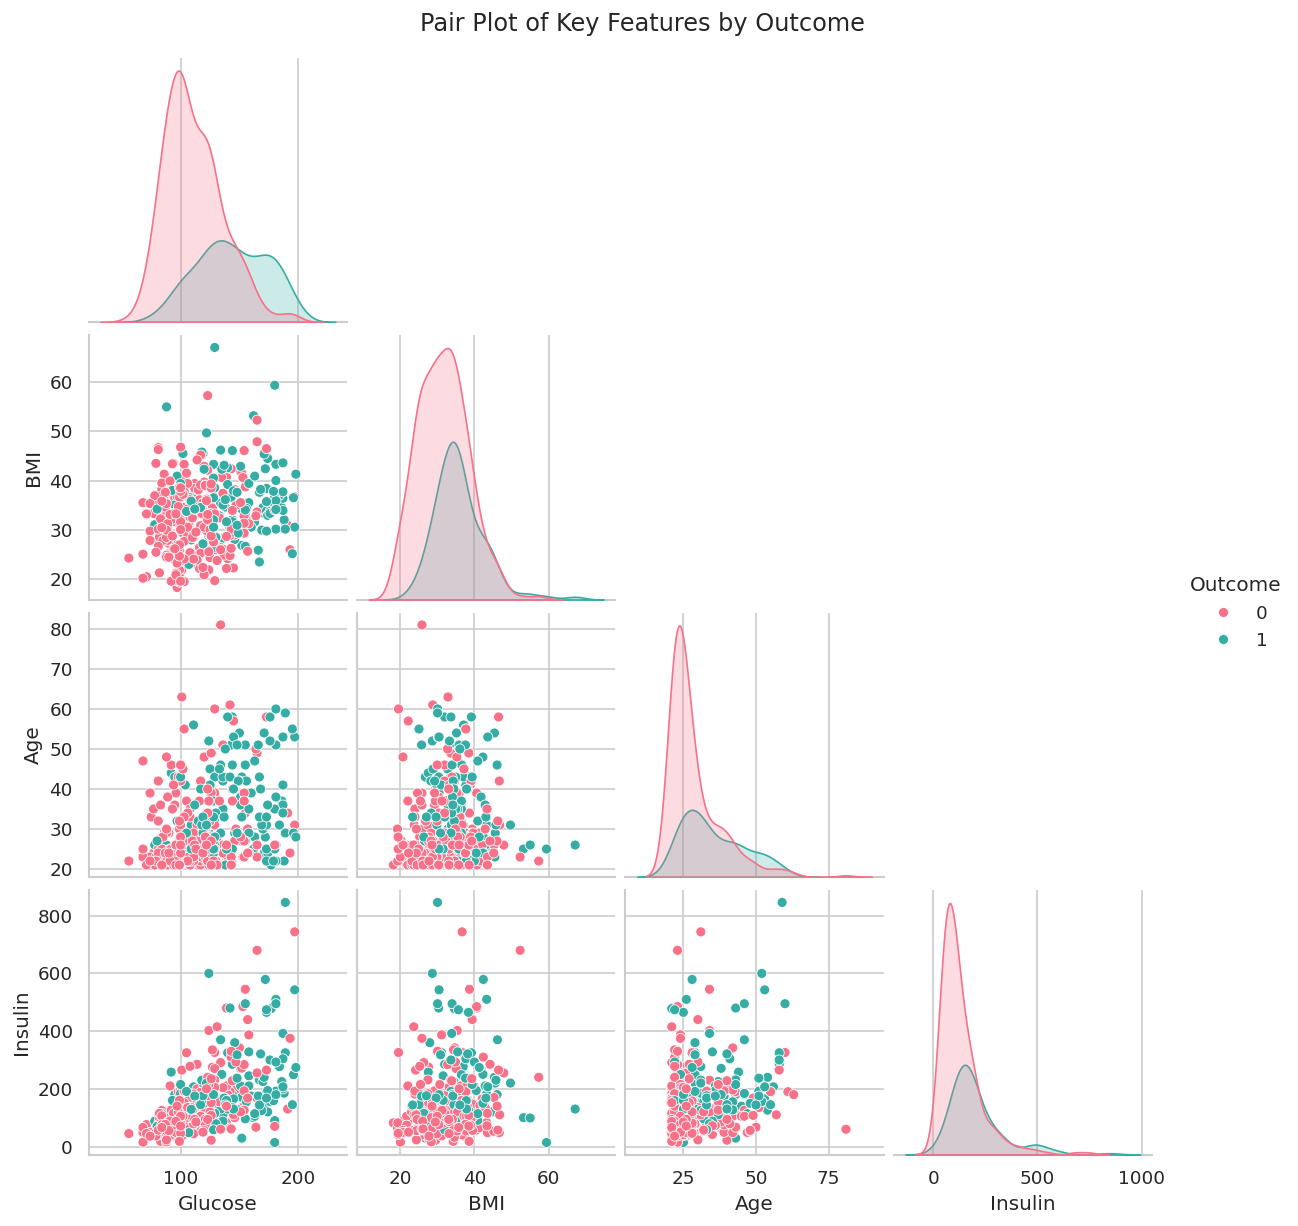

In [ ]:
if 'df_cleaned' in locals():
    pairplot_vars = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']

    valid_pairplot_vars = [v for v in pairplot_vars if v in df_cleaned.columns]
    if 'Outcome' not in valid_pairplot_vars:
        print("Warning: 'Outcome' not in DataFrame, skipping pairplot.")
    else:
        pairplot_df = df_cleaned[valid_pairplot_vars].dropna()
        if len(pairplot_df) > 1000:
            pairplot_df = pairplot_df.sample(1000, random_state=42)

        print(f'\nGenerating pairplot for {len(pairplot_df)} samples...')
        sns.pairplot(pairplot_df, hue='Outcome', corner=True, palette='husl')
        plt.suptitle('Pair Plot of Key Features by Outcome', y=1.02)
        plt.show()
else:
    print(" Error: 'df_cleaned' not created.")


**13. Outlier check for Glucose using IQR to find extreme Glucose values and show them on a boxplot**

Glucose Outlier Report (IQR Method)    
Lower bound: 36.00 | Upper bound: 204.00
Glucose outliers count: 3


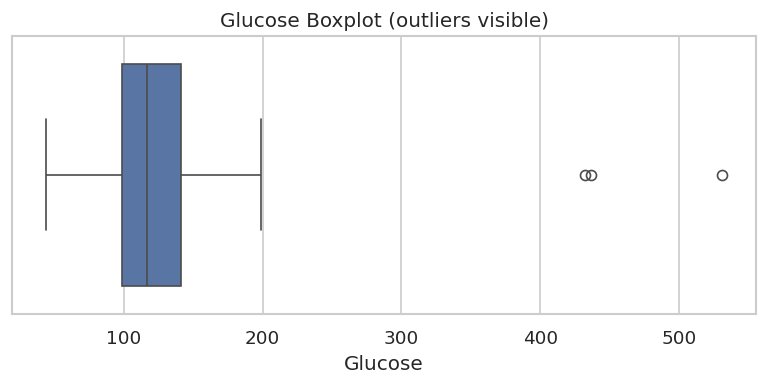

In [ ]:
if 'df_cleaned' in locals():
    if 'Glucose' in df_cleaned.columns:
        col = 'Glucose'
        q1 = df_cleaned[col].quantile(0.25)
        q3 = df_cleaned[col].quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outliers = df_cleaned[(df_cleaned[col] < lower) | (df_cleaned[col] > upper)][col]
        print(f"{col} Outlier Report (IQR Method)    ")
        print(f"Lower bound: {lower:.2f} | Upper bound: {upper:.2f}")
        print(f"{col} outliers count: {len(outliers)}")
        plt.figure(figsize=(8, 3))
        sns.boxplot(x=df_cleaned[col].dropna())
        plt.title('Glucose Boxplot (outliers visible)')
        plt.show()

    else:
        print("Warning: 'Glucose' column not found for outlier detection.")
else:
    print(" Error: 'df_cleaned' not created.")

 The outlier check on `Glucose` found 3 outliers using the IQR method.

**14. Imputation diagnostics of the dataset for the prepration of data**

In [ ]:
if 'df_cleaned' in locals():
    cols_with_zeros = ['Glucose', 'BloodPressure', 'BMI', 'SkinThickness', 'Insulin']
    for col in cols_with_zeros:
        if col in df_cleaned.columns:
            n_missing = df_cleaned[col].isnull().sum()
            pct_missing = (n_missing / len(df_cleaned) * 100)
            median_val = df_cleaned[col].median()
            mean_val = df_cleaned[col].mean()
            print(f"* {col}: missing={n_missing} ({pct_missing:.1f}%), median={median_val:.2f}, mean={mean_val:.2f}")
else:
    print(" Error: 'df_cleaned' not created")


* Glucose: missing=5 (0.6%), median=117.00, mean=122.65
* BloodPressure: missing=37 (4.6%), median=72.00, mean=72.36
* BMI: missing=26 (3.3%), median=32.30, mean=32.43
* SkinThickness: missing=245 (30.7%), median=29.00, mean=29.02
* Insulin: missing=397 (49.7%), median=125.00, mean=153.72


**15. Saving a copy of the cleaned dataset**


In [ ]:
if 'df_cleaned' in locals():
    # This saves my 'df_cleaned' so it can load it in the next step (Data Prep).
    cleaned_file = 'diabetes_cleaned_for_prep.csv'
    df_cleaned.to_csv(cleaned_file, index=False)
    print(f"\n Saved cleaned dataset to: {cleaned_file}")

else:
    print(" Error: 'df_cleaned' not created, run cell 5")



 Saved cleaned dataset to: diabetes_cleaned_for_prep.csv


# **DATA PREPRATION, PREPROCESSING AND MODELLING**

**16. Dataset size and remaining missing values**

In [ ]:
seed = 42
df = pd.read_csv("diabetes_cleaned_for_prep.csv")
print("\nNumber of rows and columns:",df.shape)

print("\nMissing values in each column:\n")
print(df.isnull().sum())


Number of rows and columns: (798, 11)

Missing values in each column:

Pregnancies                   0
Glucose                       5
BloodPressure                37
SkinThickness               245
Insulin                     397
BMI                          26
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
PhysicalActivityLevel         0
FamilyHistory               432
dtype: int64


This result shows that my  diabetes dataset has 798 rows and 11 columns. From the missing values, I can see that some features still have a lot of empty values, especially SkinThickness, Insulin and FamilyHistory, while columns like Pregnancies, Age and Outcome do not have any missing data.

**17.Train / Validation / Test split with no features**

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove("Outcome")
X_num = df[num_cols]
y = df["Outcome"]

imp_base = SimpleImputer(strategy="median")
X_num_imp = imp_base.fit_transform(X_num)

X_tmp, X_test_b, y_tmp, y_test_b = train_test_split(
    X_num_imp, y, test_size=0.2, random_state=seed, stratify=y
)

X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=seed, stratify=y_tmp
)

print("Basic shapes:")
print("Train:", X_train_b.shape, " Val:", X_val_b.shape, " Test:", X_test_b.shape)


Basic shapes:
Train: (478, 9)  Val: (160, 9)  Test: (160, 9)


Here, I only use the original numeric columns, fill their missing values with the median, and then split the data into three parts for training, validation and testing. The printed shapes tell me that the baseline setup has 478 rows for training, 160 rows for validation and 160 rows for testing, each with 9 numeric input features.

 **18.Logistic model**

In [ ]:
def score_set(y_true, y_pred):
    a = accuracy_score(y_true, y_pred)
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f = f1_score(y_true, y_pred, zero_division=0)
    return a, p, r, f

def show_scores(label, scores):
    a, p, r, f = scores
    print(label,
          "acc =", round(a, 3),
          "prec =", round(p, 3),
          "rec =", round(r, 3),
          "f1 =", round(f, 3))

log_base = LogisticRegression(max_iter=200, solver="liblinear")
log_base.fit(X_train_b, y_train_b)

pred_tr_b = log_base.predict(X_train_b)
pred_va_b = log_base.predict(X_val_b)
pred_te_b = log_base.predict(X_test_b)

sc_tr_b = score_set(y_train_b, pred_tr_b)
sc_va_b = score_set(y_val_b, pred_va_b)
sc_te_b = score_set(y_test_b, pred_te_b)

print("Logistic Model Results:")
show_scores("Train:", sc_tr_b)
show_scores("Valid:", sc_va_b)
show_scores("Test :", sc_te_b)


Logistic Model Results:
Train: acc = 0.799 prec = 0.759 rec = 0.612 f1 = 0.678
Valid: acc = 0.719 prec = 0.639 rec = 0.418 f1 = 0.505
Test : acc = 0.694 prec = 0.562 rec = 0.491 f1 = 0.524


In this step I trained a logistic regression model using only the original numeric features after filling missing values with the median. The test accuracy is about 0.694 with lower precision and recall, so this model becomes my starting point and I use it to show that later models like tree, SVM and random forest give better results than this simple baseline.

 **19.Feature engineering (Age, BMI, Pregnancies groups) and scaling**

In [ ]:
df2 = df.copy()
df2["Age_bin"] = pd.cut(
    df2["Age"],
    bins=[20, 30, 40, 50, 60, 90],
    labels=["21_30", "31_40", "41_50", "51_60", "61_plus"]
)

df2["BMI_bin"] = pd.cut(
    df2["BMI"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Under", "Normal", "Over", "Obese"]
)
df2["Preg_bin"] = pd.cut(
    df2["Pregnancies"],
    bins=[-1, 0, 3, 6, 20],
    labels=["None", "Low", "Mid", "High"]
)

if 'FamilyHistory' in df2.columns:
    df2 = df2.dropna(subset=["FamilyHistory"])
else:
    print("Warning: 'FamilyHistory' column not found in df2. Skipping dropna for it.")

columns_to_dummy = []
if 'FamilyHistory' in df2.columns:
    columns_to_dummy.append('FamilyHistory')
if 'Age_bin' in df2.columns:
    columns_to_dummy.append('Age_bin')
if 'BMI_bin' in df2.columns:
    columns_to_dummy.append('BMI_bin')
if 'Preg_bin' in df2.columns:
    columns_to_dummy.append('Preg_bin')

if columns_to_dummy:
    df2 = pd.get_dummies(
        df2,
        columns=columns_to_dummy,
        drop_first=True
    )
else:
    print("Warning: No valid columns found for one-hot encoding.")

feat_cols = [c for c in df2.columns if c != "Outcome"]

X = df2[feat_cols]
y2 = df2["Outcome"]

imp_full = SimpleImputer(strategy="median")
X_imp = imp_full.fit_transform(X)

X_tmp2, X_test, y_tmp2, y_test = train_test_split(
    X_imp, y2, test_size=0.2, random_state=seed, stratify=y2
)

X_train, X_val, y_train, y_val = train_test_split(
    X_tmp2, y_tmp2, test_size=0.25, random_state=seed, stratify=y_tmp2
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print("Engineered and scaled shapes:")
print("Train:", X_train_s.shape, " Val:", X_val_s.shape, " Test:", X_test_s.shape)


Engineered and scaled shapes:
Train: (219, 20)  Val: (73, 20)  Test: (74, 20)


In this part of the code I first created new groups for age, BMI and pregnancies, turned the text columns into numbers, filled any missing values and then scaled all the features. After that I split the data into train, validation and test sets, and the output tells me I now have 219 training rows, 73 validation rows and 74 test rows, each with 20 input features

**20.Decision tree and SVM on engineered, scaled features**

In [ ]:
tree = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=seed
)

svm = SVC(
    kernel="rbf",
    C=2.0,
    gamma="scale",
    probability=True,
    random_state=seed
)

tree.fit(X_train_s, y_train)
svm.fit(X_train_s, y_train)

pred_tr_t = tree.predict(X_train_s)
pred_va_t = tree.predict(X_val_s)
pred_te_t = tree.predict(X_test_s)

pred_tr_s = svm.predict(X_train_s)
pred_va_s = svm.predict(X_val_s)
pred_te_s = svm.predict(X_test_s)

sc_tr_t = score_set(y_train, pred_tr_t)
sc_va_t = score_set(y_val, pred_va_t)
sc_te_t = score_set(y_test, pred_te_t)

sc_tr_s = score_set(y_train, pred_tr_s)
sc_va_s = score_set(y_val, pred_va_s)
sc_te_s = score_set(y_test, pred_te_s)

print("Decision tree model results with engineered features:")
show_scores("Train:", sc_tr_t)
show_scores("Valid:", sc_va_t)
show_scores("Test :", sc_te_t)

print("\nSVM Model results:")
show_scores("Train:", sc_tr_s)
show_scores("Valid:", sc_va_s)
show_scores("Test :", sc_te_s)


Decision tree model results with engineered features:
Train: acc = 0.886 prec = 0.892 rec = 0.822 f1 = 0.855
Valid: acc = 0.726 prec = 0.679 rec = 0.633 f1 = 0.655
Test : acc = 0.757 prec = 0.741 rec = 0.645 f1 = 0.69

SVM Model results:
Train: acc = 0.89 prec = 0.934 rec = 0.789 f1 = 0.855
Valid: acc = 0.74 prec = 0.739 rec = 0.567 f1 = 0.642
Test : acc = 0.838 prec = 0.88 rec = 0.71 f1 = 0.786


Their decision tree reaches about 75.7% accuracy on the test set, with precision 0.741, recall 0.645 and F1‑score 0.690, so it gives a reasonable but not top result. The SVM does better on the test set with accuracy 0.838, precision 0.880, recall 0.710 and F1‑score 0.786, meaning it predicts the positive cases more reliably than the tree.

**21. Random forest, gradient boosting, and soft voting**

In [ ]:
rf = RandomForestClassifier(
    n_estimators=220,
    max_depth=8,
    min_samples_split=8,
    min_samples_leaf=3,
    random_state=seed
)

gb = GradientBoostingClassifier(
    n_estimators=160,
    learning_rate=0.08,
    max_depth=3,
    random_state=seed
)

rf.fit(X_train_s, y_train)
gb.fit(X_train_s, y_train)

pred_tr_rf = rf.predict(X_train_s)
pred_va_rf = rf.predict(X_val_s)
pred_te_rf = rf.predict(X_test_s)

pred_tr_gb = gb.predict(X_train_s)
pred_va_gb = gb.predict(X_val_s)
pred_te_gb = gb.predict(X_test_s)

sc_tr_rf = score_set(y_train, pred_tr_rf)
sc_va_rf = score_set(y_val, pred_va_rf)
sc_te_rf = score_set(y_test, pred_te_rf)

sc_tr_gb = score_set(y_train, pred_tr_gb)
sc_va_gb = score_set(y_val, pred_va_gb)
sc_te_gb = score_set(y_test, pred_te_gb)

print("Random forest results:")
show_scores("Train:", sc_tr_rf)
show_scores("Valid:", sc_va_rf)
show_scores("Test :", sc_te_rf)

print("\nGradient boosting results:")
show_scores("Train:", sc_tr_gb)
show_scores("Valid:", sc_va_gb)
show_scores("Test :", sc_te_gb)

vote = VotingClassifier(
    estimators=[("rf", rf), ("gb", gb), ("svm", svm)],
    voting="soft"
)

vote.fit(X_train_s, y_train)

pred_tr_v = vote.predict(X_train_s)
pred_va_v = vote.predict(X_val_s)
pred_te_v = vote.predict(X_test_s)

sc_tr_v = score_set(y_train, pred_tr_v)
sc_va_v = score_set(y_val, pred_va_v)
sc_te_v = score_set(y_test, pred_te_v)

print("\nSoft voting ensemble results:")
show_scores("Train:", sc_tr_v)
show_scores("Valid:", sc_va_v)
show_scores("Test :", sc_te_v)


Random forest results:
Train: acc = 0.913 prec = 0.928 rec = 0.856 f1 = 0.89
Valid: acc = 0.726 prec = 0.667 rec = 0.667 f1 = 0.667
Test : acc = 0.824 prec = 0.781 rec = 0.806 f1 = 0.794

Gradient boosting results:
Train: acc = 1.0 prec = 1.0 rec = 1.0 f1 = 1.0
Valid: acc = 0.74 prec = 0.657 rec = 0.767 f1 = 0.708
Test : acc = 0.797 prec = 0.75 rec = 0.774 f1 = 0.762

Soft voting ensemble results:
Train: acc = 0.954 prec = 0.988 rec = 0.9 f1 = 0.942
Valid: acc = 0.699 prec = 0.633 rec = 0.633 f1 = 0.633
Test : acc = 0.811 prec = 0.774 rec = 0.774 f1 = 0.774


In the final stage I tried several machine‑learning models on the cleaned and prepared data, including Logistic Regression, Decision Tree, SVM, Random Forest, Gradient Boosting and a soft voting model. After comparing all the results on the train, validation and test sets, the Random Forest gave the best test performance with accuracy about 0.824, precision 0.781, recall 0.806 and F1‑score 0.794. The Gradient Boosting and soft voting models were better than the simple models but still a bit worse than Random Forest, and they also showed stronger overfitting because training scores were much higher than test scores. The final accuracy  0.82 because there were too noisy data, missing values and the small dataset size.